# MMP9 Inhibitor Discovery — Data Collection & Cleaning

**Target:** Matrix Metalloproteinase-9 (MMP9) — ChEMBL ID: CHEMBL321  
**Objective:** Build a binary classification dataset to predict MMP9 inhibitor activity  
**Data Source:** ChEMBL database (bioactivity data from published literature)

---

## Background

MMP9 is a zinc-dependent endopeptidase involved in tumor invasion, angiogenesis, and metastasis.  
Inhibiting MMP9 is a therapeutic strategy for cancer treatment.  
This pipeline fetches experimentally measured IC50 values and creates clean binary labels for ML modeling.

**Pipeline Steps:**
1. Fetch raw bioactivity data from ChEMBL API
2. Explore dataset structure and quality
3. Apply filters for data quality
4. Create binary activity labels using pChEMBL threshold
5. Save clean dataset for feature engineering

**Note:** Class imbalance, SMOTE, scaffold splitting, and feature generation are handled in the next notebook (feature_engineering.ipynb)

## 1. Imports

In [2]:
# ChEMBL Python client for bioactivity data retrieval
from chembl_webresource_client.new_client import new_client

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Target Search

Search ChEMBL for MMP9 to confirm the correct target ID.  
We specifically want **Homo sapiens** (human) MMP9 — ChEMBL ID: **CHEMBL321**  

Why human only? MMP9 from rat (CHEMBL3870) or mouse (CHEMBL2214) may have different binding characteristics  
and would reduce the biological relevance of our model for human drug discovery.

In [3]:
# Search for all MMP9 targets across species
target = new_client.target
target_query = target.search('mmp9')
targets = pd.DataFrame.from_dict(target_query)

# Display to confirm CHEMBL321 = Homo sapiens MMP9
targets[['organism', 'pref_name', 'target_chembl_id', 'target_type']].head()

,organism,pref_name,target_chembl_id,target_type
0,Rattus norvegicus,Matrix metalloproteinase-9,CHEMBL3870,SINGLE PROTEIN
1,Mus musculus,Matrix metalloproteinase-9,CHEMBL2214,SINGLE PROTEIN
2,Bos taurus,Matrix metalloproteinase-9,CHEMBL5846,SINGLE PROTEIN
3,Homo sapiens,Matrix metalloproteinase-9,CHEMBL321,SINGLE PROTEIN
4,Homo sapiens,Matrix metalloproteinase 2/9,CHEMBL3885505,PROTEIN FAMILY


## 3. Fetch Bioactivity Data

Fetch IC50 measurements for CHEMBL321 (human MMP9).  

**Why IC50?**  
IC50 (half-maximal inhibitory concentration) is the most common bioactivity measure in ChEMBL  
for enzyme inhibitors. It represents the compound concentration required to inhibit 50% of MMP9 activity.

**Why not Ki or Kd?**  
IC50 provides the largest dataset for MMP9. Ki/Kd will be explored separately in experiments.

In [4]:
# Fetch all IC50 bioactivity data for human MMP9
res = new_client.activity
res_query = res.filter(
    target_chembl_id='CHEMBL321'
).filter(
    standard_type='IC50'
)
res_df = pd.DataFrame.from_dict(res_query)
print(f"Raw records fetched: {len(res_df)}")
res_df.head()

Raw records fetched: 3964


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33892,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,34.0
1,None,None,35115,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,9.0
2,None,None,35120,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,20.0
3,None,None,35125,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,3.0
4,None,None,35129,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,9.0


## 4. Exploratory Data Analysis

Before cleaning, understand the dataset structure — number of columns, null values, data types.  
This informs which filters are necessary and how much data will be retained.

In [5]:
# Dataset dimensions
print(f"Shape: {res_df.shape}")
print(f"Rows: {res_df.shape[0]}, Columns: {res_df.shape[1]}")

Shape: (3964, 46)
Rows: 3964, Columns: 46


In [6]:
# Data types and null counts per column
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3964 entries, 0 to 3963
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                202 non-null    object 
 1   activity_comment           1124 non-null   object 
 2   activity_id                3964 non-null   int64  
 3   activity_properties        3964 non-null   object 
 4   assay_chembl_id            3964 non-null   object 
 5   assay_description          3964 non-null   object 
 6   assay_type                 3964 non-null   object 
 7   assay_variant_accession    17 non-null     object 
 8   assay_variant_mutation     17 non-null     object 
 9   bao_endpoint               3964 non-null   object 
 10  bao_format                 3964 non-null   object 
 11  bao_label                  3964 non-null   object 
 12  canonical_smiles           3927 non-null   object 
 13  data_validity_comment      86 non-null     objec

In [7]:
# All column names for reference
res_df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

## 5. pChEMBL Value Analysis

**pChEMBL = -log10(IC50 in molar)**  
ChEMBL standardizes all activity values to this scale — no manual unit conversion needed.  

**Threshold:** pChEMBL ≥ 5.4 = IC50 ≤ 5μM = **ACTIVE**  
**Rationale:** 5μM is a common threshold in QSAR literature for MMP inhibitors,  
representing therapeutic relevance while retaining sufficient data points.

Note: pChEMBL column is stored as object dtype — convert to numeric first.

In [8]:
# Check pChEMBL distribution before conversion
print("pChEMBL value statistics (before numeric conversion):")
print(res_df['pchembl_value'].describe())

pChEMBL value statistics (before numeric conversion):
count     2411
unique     490
top       8.70
freq        54
Name: pchembl_value, dtype: object


In [9]:
# Convert pChEMBL to numeric — errors='coerce' converts non-numeric to NaN
res_df['pchembl_value'] = pd.to_numeric(res_df['pchembl_value'], errors='coerce')
print(f"Records with valid pChEMBL values: {res_df['pchembl_value'].notna().sum()}")
print(f"Records missing pChEMBL: {res_df['pchembl_value'].isna().sum()}")

Records with valid pChEMBL values: 2411
Records missing pChEMBL: 1553


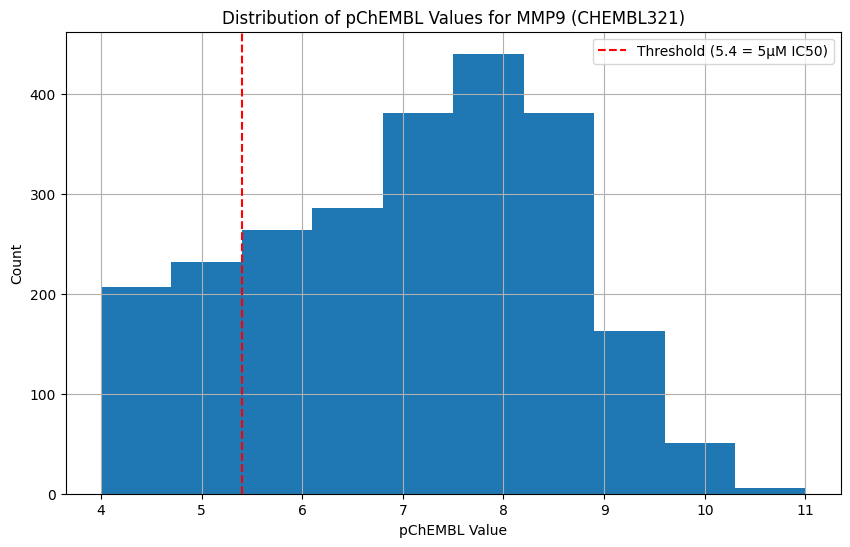


Observation: Bimodal distribution suggests clear active/inactive separation


In [10]:
# Visualize pChEMBL distribution with activity threshold
res_df['pchembl_value'].hist(figsize=(10, 6))
plt.axvline(x=5.4, color='red', linestyle='--', label='Threshold (5.4 = 5μM IC50)')
plt.xlabel('pChEMBL Value')
plt.ylabel('Count')
plt.title('Distribution of pChEMBL Values for MMP9 (CHEMBL321)')
plt.legend()
plt.show()
print("\nObservation: Bimodal distribution suggests clear active/inactive separation")

## 6. Data Quality Filters

Apply sequential filters to retain only high-quality, unambiguous data.

### Filter 1: Standard Relation  
Only keep exact measurements (relation = '=').  
Inequality measurements (>, <, <=) represent compounds where the true IC50 is unknown —  
labeling them as active or inactive would introduce noise.

### Filter 2: Assay Type  
Only keep binding assays (assay_type = 'B').  
Binding assays directly measure compound-protein interaction.  
Functional assays (A) measure downstream effects and are less direct.

### Filter 3: Null Removal  
Remove rows missing pChEMBL value or SMILES string —  
both are required for labeling and feature generation respectively.

In [11]:
# Inspect standard_type distribution (should be all IC50)
print("Standard type distribution:")
print(res_df['standard_type'].value_counts())

Standard type distribution:
standard_type
IC50    3964
Name: count, dtype: int64


In [12]:
# Inspect measurement relation types
print("Standard relation distribution:")
print(res_df['standard_relation'].value_counts())
print("\nRetaining only exact measurements (relation = '=')")

Standard relation distribution:
standard_relation
=     2464
>      461
<       16
<=       2
~        1
Name: count, dtype: int64

Retaining only exact measurements (relation = '=')


In [13]:
# Filter 1: Keep exact measurements only
before = len(res_df)
res_df = res_df[res_df['standard_relation'] == '=']
print(f"After relation filter: {before} → {len(res_df)} rows ({before - len(res_df)} removed)")

# Filter 2: Remove missing pChEMBL and SMILES
before = len(res_df)
res_df = res_df.dropna(subset=['pchembl_value', 'canonical_smiles'])
print(f"After null filter: {before} → {len(res_df)} rows ({before - len(res_df)} removed)")

# Create binary activity label
# pChEMBL >= 5.4 (IC50 <= 5uM) = ACTIVE (1)
# pChEMBL < 5.4 (IC50 > 5uM) = INACTIVE (0)
res_df['bioactivity_class'] = (res_df['pchembl_value'] >= 5.4).astype(int)
print(f"\nBioactivity class distribution:")
print(res_df['bioactivity_class'].value_counts())
print(f"\nNote: Class imbalance ({res_df['bioactivity_class'].sum()} active vs {(res_df['bioactivity_class']==0).sum()} inactive) will be addressed in feature_engineering.ipynb")

After relation filter: 3964 → 2464 rows (1500 removed)
After null filter: 2464 → 2411 rows (53 removed)

Bioactivity class distribution:
bioactivity_class
1    1972
0     439
Name: count, dtype: int64

Note: Class imbalance (1972 active vs 439 inactive) will be addressed in feature_engineering.ipynb


In [14]:
# Filter 3: Assay type distribution
print("Assay type distribution:")
print(res_df['assay_type'].value_counts())
print("\nRetaining only binding assays (B) — direct protein-compound interaction measurement")

Assay type distribution:
assay_type
B    2397
A      14
Name: count, dtype: int64

Retaining only binding assays (B) — direct protein-compound interaction measurement


In [15]:
# Apply assay type filter
before = len(res_df)
res_df = res_df[res_df['assay_type'] == 'B']
print(f"After assay type filter: {before} → {len(res_df)} rows ({before - len(res_df)} removed)")
print(f"\nFinal bioactivity distribution:")
print(res_df['bioactivity_class'].value_counts())

After assay type filter: 2411 → 2397 rows (14 removed)

Final bioactivity distribution:
bioactivity_class
1    1959
0     438
Name: count, dtype: int64


## 7. Save Clean Dataset

Retain only the four columns required for downstream processing:
- `molecule_chembl_id` — unique compound identifier
- `canonical_smiles` — molecular structure (input for fingerprint generation)
- `pchembl_value` — raw activity value (useful for regression experiments later)
- `bioactivity_class` — binary label (0=inactive, 1=active) — model target

**Next steps in feature_engineering.ipynb:**
- Duplicate SMILES removal
- Morgan fingerprint generation (ECFP4, radius=2, nBits=2048)
- RDKit molecular descriptor calculation
- Balanced Weights for class imbalance
- Scaffold-based train/test split

In [16]:
# Select final columns
clean_df = res_df[[
    'molecule_chembl_id',
    'canonical_smiles',
    'pchembl_value',
    'bioactivity_class'
]]

# Save to processed data folder
output_path = '../data/processed/mmp9_clean.csv'
clean_df.to_csv(output_path, index=False)

print(f"Clean dataset saved to: {output_path}")
print(f"Final shape: {clean_df.shape}")
print(f"Active compounds: {clean_df['bioactivity_class'].sum()}")
print(f"Inactive compounds: {(clean_df['bioactivity_class']==0).sum()}")
print(f"\nReady for feature_engineering.ipynb")

Clean dataset saved to: ../data/processed/mmp9_clean.csv
Final shape: (2397, 4)
Active compounds: 1959
Inactive compounds: 438

Ready for feature_engineering.ipynb
